# 2. Labelling episodes with EVT and the channel graph

A GNN/GAT needs many **independent labelled episodes**. `EpisodeLabeler` builds them from long
recordings:

1. freeze robust scaling, the POT/GPD threshold and the channel graph on each recording's baseline;
2. find *every* persistent alarm (declustered with a refractory period), not only the first;
3. compute node features `[peak, energy, latency, degree, neighbor_peak]` for every event;
4. assign a label origin:
   * `manual` – an expert annotation `(event_time, source)` matches the detected onset;
   * `pseudo` – no annotation, but the transparent ranker is confident (weight and margin thresholds);
   * `abstained` – ambiguous, kept for inspection but not used for training.

> Pseudo-labels copy the transparent ranker. They are useful for bootstrapping, but a model
> trained only on them imitates the ranker. Always evaluate against manual labels.

In [1]:
# If the package is not installed yet (run once, then restart the kernel):
# %pip install "graph-evt-agent[notebooks] @ git+https://github.com/D2718281828nis/Graph-EVT-agent"
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

In [2]:
from graph_evt_agent import (EVTConfig, GraphConfig, GraphEVTPipeline,
                             EpisodeLabeler, LabelingConfig)
from graph_evt_agent.synthetic import make_recording
from graph_evt_agent import visualization as viz

# 12 recordings with 10 events each. gain_jitter makes some neighbors respond louder
# than the true source, so "largest peak" is not always right – like real sensors.
recordings = {f"rec{i:02d}": make_recording(n_events=10, n_channels=6, baseline_size=400,
                                            amplitude=8, gain_jitter=0.8, delay_per_hop=3,
                                            seed=SEED + i)
              for i in range(12)}
pipeline = GraphEVTPipeline(EVTConfig(baseline_size=400, persistence=3),
                            GraphConfig(method="ar", edge_threshold=0.2, random_state=SEED))
labeler = EpisodeLabeler(pipeline, LabelingConfig(min_confidence=0.5, min_margin=0.2,
                                                  refractory=50), verbose=True)

## Pseudo-labels only (no annotations)

In [3]:
pseudo = labeler.label({key: rec.as_input() for key, rec in recordings.items()})
print(pseudo.summary())
table = pd.DataFrame(pseudo.to_records())
table.head(8)

Labelling episodes:   0%|          | 0/12 [00:00<?, ?it/s]

Labelling episodes:  42%|████▏     | 5/12 [00:00<00:00, 43.72it/s, 50 events, 49 labelled]

Labelling episodes:  92%|█████████▏| 11/12 [00:00<00:00, 51.66it/s, 110 events, 109 labelled]

Labelling episodes: 100%|██████████| 12/12 [00:00<00:00, 50.71it/s, 120 events, 119 labelled]

{'episodes': 120, 'manual': 0, 'pseudo': 119, 'abstained': 1, 'skipped_series': 0}


,series_id,event_time,source,source_name,origin,confidence,margin,graph_method
0,rec00,531,2.0,ch2,pseudo,0.918200,0.867642,ar_innovation_correlation
1,rec00,777,3.0,ch3,pseudo,0.999999,0.999997,ar_innovation_correlation
2,rec00,1025,3.0,ch3,pseudo,1.000000,1.000000,ar_innovation_correlation
3,rec00,1275,2.0,ch2,pseudo,0.999095,0.998665,ar_innovation_correlation
4,rec00,1528,3.0,ch3,pseudo,0.857058,0.718160,ar_innovation_correlation
5,rec00,1775,5.0,ch5,pseudo,0.999986,0.999973,ar_innovation_correlation
6,rec00,2031,5.0,ch5,pseudo,0.999415,0.998868,ar_innovation_correlation
7,rec00,2275,3.0,ch3,pseudo,1.000000,1.000000,ar_innovation_correlation


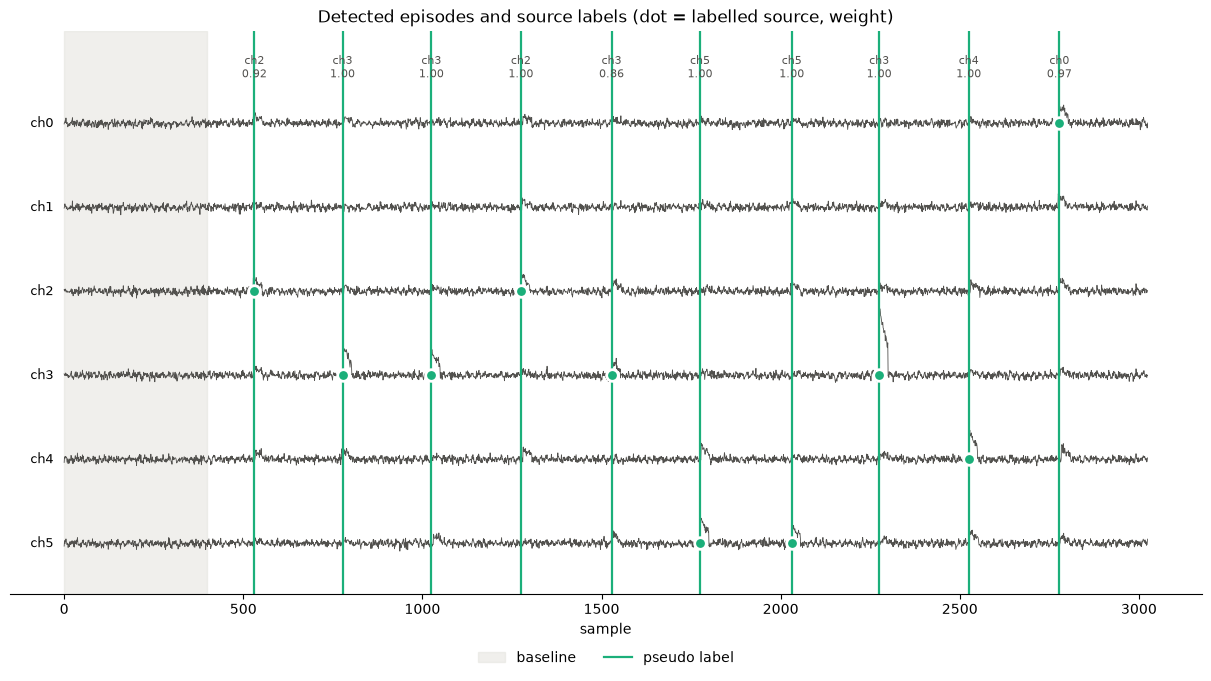

In [4]:
fig = viz.plot_labelled_recording(recordings["rec00"].values, pseudo, "rec00",
                                  channel_names=recordings["rec00"].channel_names,
                                  baseline_size=400)

## How good are the pseudo-labels?

Because the data are synthetic we know the truth, so we can measure what you usually cannot:
how often the confident heuristic label is correct.

In [5]:
def true_source(series_id, event_time):
    rec = recordings[series_id]
    nearest = int(np.argmin([abs(onset - event_time) for onset in rec.event_times]))
    return rec.sources[nearest]

table["true_source"] = [true_source(s, t) for s, t in zip(table.series_id, table.event_time)]
labelled = table[table.origin == "pseudo"]
print(f"pseudo-label accuracy: {(labelled.source == labelled.true_source).mean():.2f} "
      f"on {len(labelled)} episodes; abstained: {(table.origin == 'abstained').sum()}")

pseudo-label accuracy: 0.39 on 119 episodes; abstained: 1


## Adding expert annotations

Annotations are `(event_time, source)` pairs per recording; `source` may be a channel index or
name. A detected onset within `match_tolerance` samples inherits the manual label. Here we
annotate every event with the ground truth, as an expert would after review.

In [6]:
annotations = {key: list(zip(rec.event_times, rec.sources)) for key, rec in recordings.items()}
manual = labeler.label({key: rec.as_input() for key, rec in recordings.items()}, annotations)
print(manual.summary())
# Save for the next notebook / other programs
pd.DataFrame(manual.to_records()).to_csv("labelled_episodes.csv", index=False)

Labelling episodes:   0%|          | 0/12 [00:00<?, ?it/s]

Labelling episodes:  42%|████▏     | 5/12 [00:00<00:00, 45.94it/s, 50 events, 50 labelled]

Labelling episodes: 100%|██████████| 12/12 [00:00<00:00, 55.22it/s, 120 events, 120 labelled]

Labelling episodes: 100%|██████████| 12/12 [00:00<00:00, 53.50it/s, 120 events, 120 labelled]

{'episodes': 120, 'manual': 120, 'pseudo': 0, 'abstained': 0, 'skipped_series': 0}


In practice you would annotate only part of the recordings, train on
`origins=("manual", "pseudo")`, and keep manually labelled recordings for validation.
Continue with **03_train_gnn_gat.ipynb**.